<a href="https://colab.research.google.com/github/sabdashy/Matkul_MachineLearning/blob/tugas/Notebook/Tugas/Tugas06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
path = "/content/gdrive/MyDrive/MataKuliahSTTNF/Semester7/MachineLearning/praktikum_ml/praktikum06"

In [ ]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:

# Baca dan bersihkan dataset
data = pd.read_csv(path + "/data/data.csv") # sesuaikan path di Colab
data = data.drop(['id', 'Unnamed: 32'], axis=1)

In [ ]:
# Pisahkan fitur (X) dan target (y)
X = data.drop('diagnosis', axis=1)
y = data['diagnosis'].map({'M': 1, 'B': 0})  # ubah label jadi numerik

In [ ]:
data.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:

# Split data (latih dan uji)
# test_size=0.2 berarti 20% data untuk testing, 80% untuk training
# random_state=42 agar hasil pembagian konsisten setiap kali dijalankan
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Normalisasi data
# SVM sensitif terhadap skala data, jadi semua fitur harus distandarkan
# Membuat objek scaler
scaler = StandardScaler()

# Hitung rata-rata dan deviasi, lalu ubah data latih
X_train_scaled = scaler.fit_transform(X_train)

# Gunakan hasil dari data latih untuk ubah data uji
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Latih model SVM
# Membuat model SVM dengan kernel RBF
# - kernel='rbf' artinya menggunakan fungsi basis radial
# - C=1 mengontrol penalti kesalahan (semakin besar C, semakin keras batasnya)
# - gamma='scale' menyesuaikan otomatis berdasarkan data
svm_model = SVC(kernel='rbf', C=1, gamma='scale', probability=True)

# Melatih model menggunakan data latih
svm_model.fit(X_train_scaled, y_train)

SVC(C=1, probability=True)

In [ ]:
# Evaluasi model
# Prediksi kelas pada data uji
y_pred = svm_model.predict(X_test_scaled)

# Menampilkan nilai akurasi model
print("Akurasi:", accuracy_score(y_test, y_pred))

# Menampilkan laporan klasifikasi
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Menampilkan confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Akurasi: 0.9824561403508771

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99        71
           1       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


Confusion Matrix:
 [[71  0]
 [ 2 41]]


In [ ]:
# Reduksi dimensi dengan PCA
 # Membuat objek PCA yang akan mengurangi fitur menjadi 2 komponen utama
pca_2d = PCA(n_components=2)

# Menerapkan PCA ke data latih yang sudah distandarisasi
X_pca_2d = pca_2d.fit_transform(X_train_scaled)

# Membuat objek PCA yang akan mengurangi fitur menjadi 3 komponen utama
pca_3d = PCA(n_components=3)

# Menerapkan PCA ke data latih yang sudah distandarisasi
X_pca_3d = pca_3d.fit_transform(X_train_scaled)

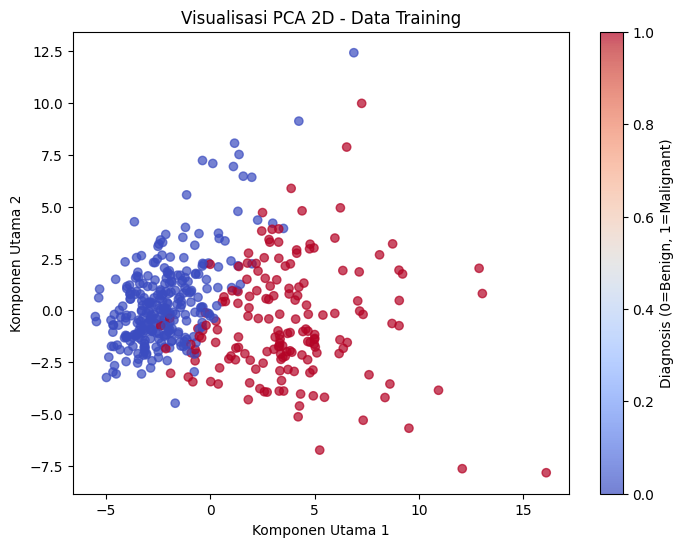

In [ ]:
# Visualisasi 2D hasil PCA
# Membuat figure baru dengan ukuran 8x6 inci
plt.figure(figsize=(8,6))

# Membuat scatter plot (diagram sebar) menggunakan hasil reduksi PCA 2 dimensi
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_train, cmap='coolwarm', alpha=0.7)

# Menambahkan judul pada grafik
plt.title("Visualisasi PCA 2D - Data Training")

# Memberi label pada sumbu X dan Y
plt.xlabel("Komponen Utama 1")
plt.ylabel("Komponen Utama 2")

# Menambahkan colorbar (indikator warna) untuk menunjukkan arti warna (0 = jinak, 1 = ganas)
plt.colorbar(label="Diagnosis (0=Benign, 1=Malignant)")
plt.show()

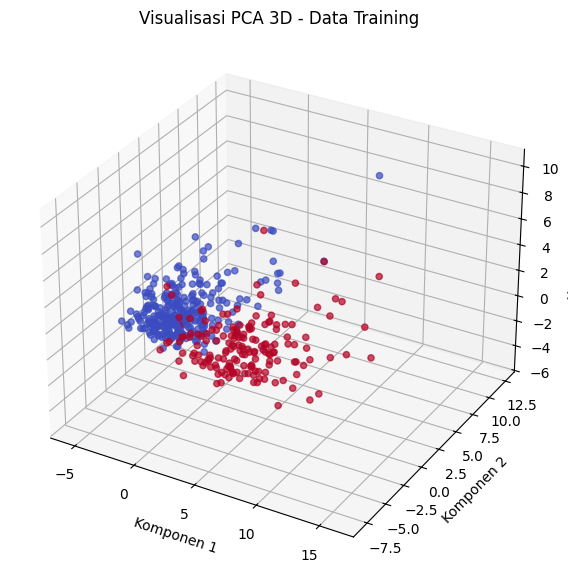

In [ ]:
# Visualisasi 3D hasil PCA
# Import modul Axes3D dari mpl_toolkits.mplot3d untuk membuat plot 3 dimensi
from mpl_toolkits.mplot3d import Axes3D

# Membuat figure baru dengan ukuran 9x7 inci
fig = plt.figure(figsize=(9,7))

# Menambahkan subplot dengan proyeksi '3d' ke dalam figure
ax = fig.add_subplot(111, projection='3d')

# Membuat scatter plot (diagram sebar) dalam ruang 3 dimensi
ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y_train, cmap='coolwarm', alpha=0.7)

# Menambahkan judul pada grafik 3D
ax.set_title("Visualisasi PCA 3D - Data Training")

# Memberi label pada masing-masing sumbu
ax.set_xlabel("Komponen 1")
ax.set_ylabel("Komponen 2")
ax.set_zlabel("Komponen 3")

# Menampilkan plot ke layar
plt.show()